Cargamos el dataset limpio y con las columnas calculadas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

final_df = pd.read_csv("final_dataset.csv", parse_dates=["date"])

print("Shape:", final_df.shape)
print(final_df.describe().T)

Shape: (216549, 26)
                       count         mean           std          min  \
workout_time        216549.0  3128.546571   1959.063473     2.000000   
total_distance      216549.0     9.166435      5.712672     0.003620   
elevation_gain      188739.0  1050.678843  42302.680234     0.010000   
average_hr          177702.0   146.388455     14.546608    60.000000   
age                 216549.0    44.168798     11.464709    12.000000   
activities          216549.0  1161.218500    914.038487     1.000000   
run                 216549.0   521.017636    567.978271     1.000000   
weightkg            216549.0    73.907193      9.275184    38.000000   
pace_min_km         216549.0     5.806927      1.127388     3.001141   
year                216549.0  2016.916661      2.037926  2007.000000   
month               216549.0     6.400782      3.530733     1.000000   
pace_kmh            216549.0    10.685764      1.887311     6.000000   
n_activities_run    216549.0   494.518954   

# 🎯 Objetivo del análisis

¿Qué factores relacionados con las características y el entrenamiento de un corredor están asociados con un mejor rendimiento en running?

Variable objetivo: pace_min_km (a nivel actividad) y avg_pace (a nivel atleta). Menor valor = mejor rendimiento.

# 1. Contexto

In [3]:
# --- 1.1 Volumen general ---
print("Nº de actividades (filas):", len(final_df))
print("Nº de atletas únicos:", final_df["id"].nunique())
print("Media de actividades por atleta:", len(final_df) / final_df["id"].nunique())

Nº de actividades (filas): 216549
Nº de atletas únicos: 2379
Media de actividades por atleta: 91.02522068095838


Aunque casi la mitad de los atletas son "principiantes" (pocas actividades registradas), estos apenas representan el 3.3% del total de filas — mientras que el 24.9% "avanzados" concentran el 82.6% de las actividades.

A tener en cuenta que, estamos mirando mayoritariamente el comportamiento de un grupo reducido de corredores muy activos, no una muestra representativa de "corredores en general".

In [4]:
# --- 1.2 Distribución de experience_level ---
athletes_unique = final_df.drop_duplicates(subset="id")

print("Distribución de experience_level (nº de atletas):")
print(athletes_unique["experience_level"].value_counts())
print("\n% sobre el total de atletas:")
print((athletes_unique["experience_level"].value_counts(normalize=True) * 100).round(1))

print("\nDistribución de experience_level (nº de actividades):")
print(final_df["experience_level"].value_counts(normalize=True).mul(100).round(1))

Distribución de experience_level (nº de atletas):
experience_level
principiante    1163
intermedio       623
avanzado         593
Name: count, dtype: int64

% sobre el total de atletas:
experience_level
principiante    48.9
intermedio      26.2
avanzado        24.9
Name: proportion, dtype: float64

Distribución de experience_level (nº de actividades):
experience_level
avanzado        82.6
intermedio      14.1
principiante     3.3
Name: proportion, dtype: float64


Género muy desbalanceado - 96.9% hombres vs 3.1% mujeres - cualquier comparación por género tendrá muy poca potencia estadística en el grupo femenino

In [5]:
# --- 1.3 Edad y género ---
print("Distribución de género (atletas únicos):")
print(athletes_unique["gender"].value_counts(normalize=True).mul(100).round(1))

print("\nEstadísticos de edad (atletas únicos, corregida):")
print(athletes_unique["age"].describe())

Distribución de género (atletas únicos):
gender
M    96.9
F     3.1
Name: proportion, dtype: float64

Estadísticos de edad (atletas únicos, corregida):
count    2379.000000
mean       42.062631
std        12.072421
min        12.000000
25%        34.000000
50%        42.000000
75%        50.000000
max        79.000000
Name: age, dtype: float64


Edad: distribución razonable, centrada en 40-42 años, rango 12-79. El histograma muestra una forma bastante normal, nada que llame la atención.

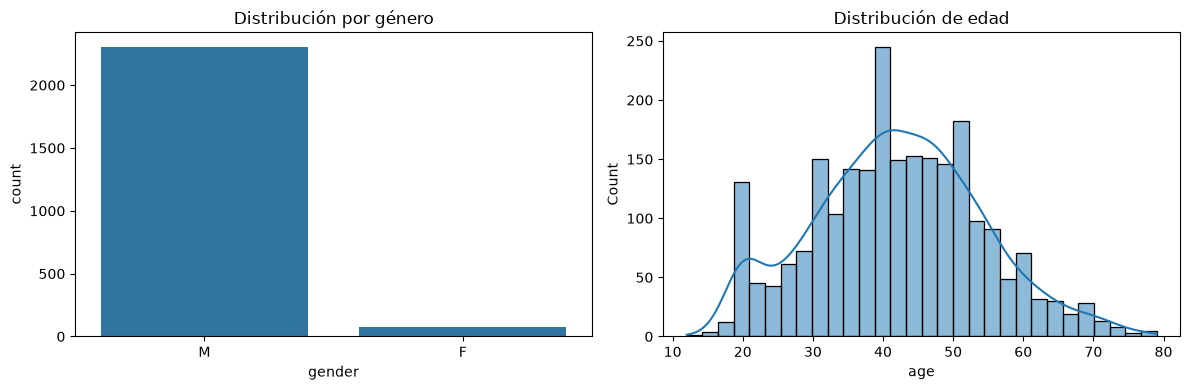

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=athletes_unique, x="gender", ax=axes[0])
axes[0].set_title("Distribución por género")

sns.histplot(data=athletes_unique, x="age", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribución de edad")
plt.tight_layout()
plt.show()

# 2. Información variable objetivo

El pace medio por actividad (5.81 min/km) es más rápido que el pace medio por atleta (6.24 min/km), reflejando que los corredores más activos — que generan más registros — tienden a tener mejor rendimiento. Esto confirma la necesidad de distinguir entre análisis a nivel actividad y a nivel atleta.

In [7]:
# --- Creamos función para convertir minutos a formato min:seg ---
def min_a_min_seg(valor_decimal):
    minutos = int(valor_decimal)
    segundos = round((valor_decimal - minutos) * 60)
    return f"{minutos}:{segundos:02d}"

count    216549.000000
mean          5.806927
std           1.127388
min           3.001141
25%           5.034762
50%           5.583458
75%           6.319487
max          10.000000
Name: pace_min_km, dtype: float64


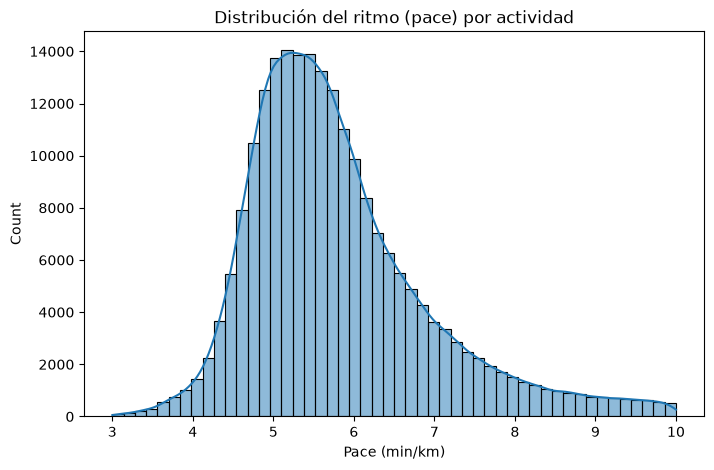

In [8]:
# --- 2.1 Distribución de pace a nivel actividad ---
print(final_df["pace_min_km"].describe())

plt.figure(figsize=(8,5))
sns.histplot(final_df["pace_min_km"], bins=50, kde=True)
plt.title("Distribución del ritmo (pace) por actividad")
plt.xlabel("Pace (min/km)")
plt.show()

count    2379.000000
mean        6.243192
std         1.059581
min         3.245695
25%         5.503842
50%         6.022044
75%         6.764013
max         9.990555
Name: avg_pace, dtype: float64


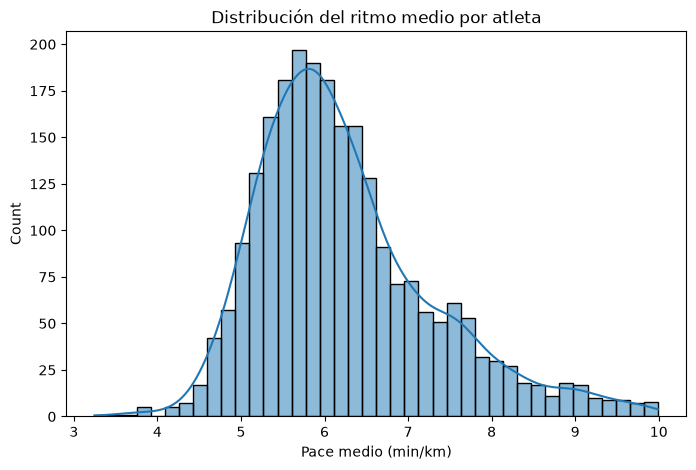

In [9]:
# --- 2.2 Distribución de avg_pace a nivel atleta (más representativa, 1 fila = 1 atleta) ---
print(athletes_unique["avg_pace"].describe())

plt.figure(figsize=(8,5))
sns.histplot(athletes_unique["avg_pace"], bins=40, kde=True)
plt.title("Distribución del ritmo medio por atleta")
plt.xlabel("Pace medio (min/km)")
plt.show()

El 10% más rápido corre a 5:07 min/km, mientras que el 10% más lento lo hace a 7:43 min/km — una diferencia de 2:36 min/km entre ambos extremos.

In [10]:
# --- 2.3 Percentiles clave: ¿qué pace te sitúa en el top 10%? ---
percentiles = athletes_unique["avg_pace"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
print("Percentiles de avg_pace (atleta):")
for q, valor in percentiles.items():
    print(f"P{int(q*100)}: {min_a_min_seg(valor)} min/km")
diferencia_percentiles = percentiles.loc[0.9] - percentiles.loc[0.1]
print("\nDiferencia entre el 10% más rápido y el 10% más lento:", min_a_min_seg(diferencia_percentiles))

Percentiles de avg_pace (atleta):
P10: 5:07 min/km
P25: 5:30 min/km
P50: 6:01 min/km
P75: 6:46 min/km
P90: 7:43 min/km

Diferencia entre el 10% más rápido y el 10% más lento: 2:36


# 3. Entrenamiento vs Rendimiento

Correlación débil-moderada: más km semanales se asocia con mejor pace, pero no es un factor dominante por sí solo

           weekly_km  avg_pace
weekly_km   1.000000 -0.261734
avg_pace   -0.261734  1.000000


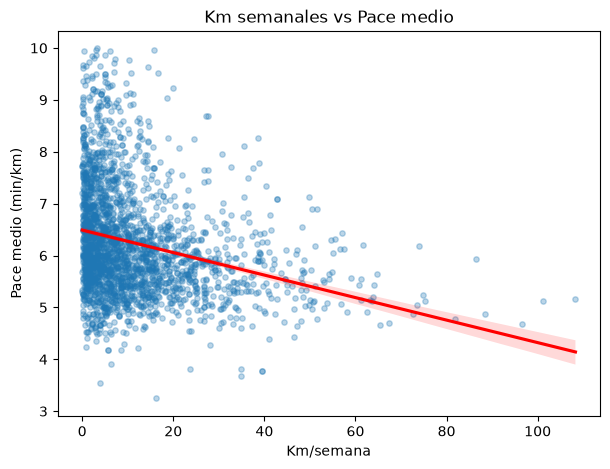

In [11]:
# --- 3.1 Volumen de entrenamiento vs rendimiento ---
print(athletes_unique[["weekly_km", "avg_pace"]].corr())

plt.figure(figsize=(7,5))
sns.regplot(data=athletes_unique, x="weekly_km", y="avg_pace",
            scatter_kws={"alpha":0.3, "s":15}, line_kws={"color":"red"})
plt.title("Km semanales vs Pace medio")
plt.xlabel("Km/semana")
plt.ylabel("Pace medio (min/km)")
plt.show()

Correlación aún más débil: entrenar más veces por semana pesa menos que el volumen total (weekly_km)

                    training_frequency  avg_pace
training_frequency             1.00000  -0.15646
avg_pace                      -0.15646   1.00000


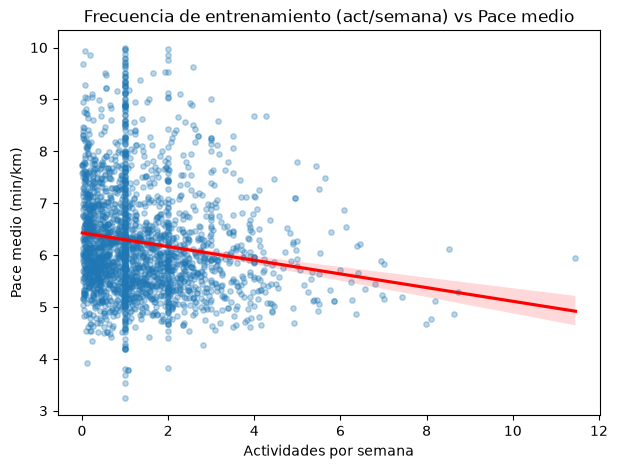

In [12]:
# --- 3.2 Frecuencia de entrenamiento vs rendimiento ---
print(athletes_unique[["training_frequency", "avg_pace"]].corr())

plt.figure(figsize=(7,5))
sns.regplot(data=athletes_unique, x="training_frequency", y="avg_pace",
            scatter_kws={"alpha":0.3, "s":15}, line_kws={"color":"red"})
plt.title("Frecuencia de entrenamiento (act/semana) vs Pace medio")
plt.xlabel("Actividades por semana")
plt.ylabel("Pace medio (min/km)")
plt.show()

no solo los avanzados corren más rápido de media, sino que son mucho más consistentes entre sí (desviación estándar menor). Los principiantes muestran una variabilidad enorme — desde gente muy rápida (min=3:15) hasta muy lenta (max=9:59). Esto tiene sentido: "principiante" según nuestra definición (basada en nº de actividades registradas) no distingue entre alguien nuevo en el running en general y alguien con más experiencia real pero que empezó a usar la app hace poco.

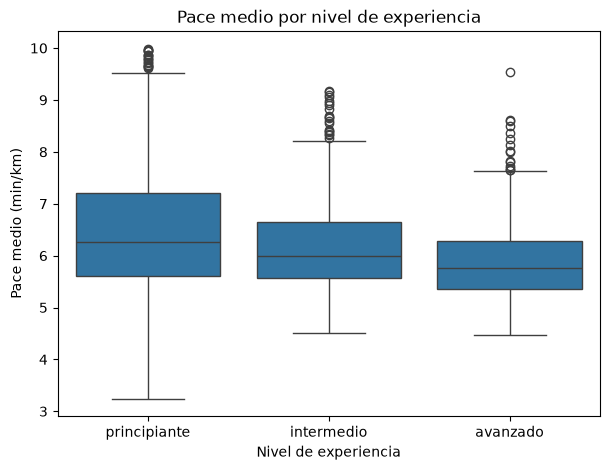

                   count      mean       std       min       25%       50%  \
experience_level                                                             
avanzado           593.0  5.863213  0.712567  4.479926  5.360478  5.767676   
intermedio         623.0  6.178073  0.894307  4.508424  5.562876  5.990616   
principiante      1163.0  6.471822  1.217592  3.245695  5.610801  6.254804   

                       75%       max  
experience_level                      
avanzado          6.272875  9.532790  
intermedio        6.646131  9.171548  
principiante      7.204592  9.990555  


In [13]:
# --- 3.3 Pace por nivel de experiencia (boxplot comparativo) ---
plt.figure(figsize=(7,5))
sns.boxplot(data=athletes_unique, x="experience_level", y="avg_pace",
            order=["principiante","intermedio","avanzado"])
plt.title("Pace medio por nivel de experiencia")
plt.xlabel("Nivel de experiencia")
plt.ylabel("Pace medio (min/km)")
plt.show()

print(athletes_unique.groupby("experience_level")["avg_pace"].describe())

Los corredores clasificados como avanzados presentan un pace medio un 9% más rápido que los principiantes (5:52 vs 6:28 min/km), y sobre todo mucho más consistente (menor variabilidad). El volumen de entrenamiento semanal muestra una asociación negativa moderada con el pace (r=-0.26), mientras que la frecuencia de entrenamiento tiene una relación más débil (r=-0.16), sugiriendo que la cantidad de kilómetros importa más que el número de sesiones.

# 4. Perfil del corredor: edad, sexo, peso

Edad vs pace: correlación positiva pero muy débil (r=0.11). Como el pace está en min/km (mayor = más lento), esto significa que a más edad, ligerísimamente peor ritmo — pero la relación es tan débil que prácticamente no hay asociación relevante en esta muestra.

               age  avg_pace
age       1.000000  0.105293
avg_pace  0.105293  1.000000


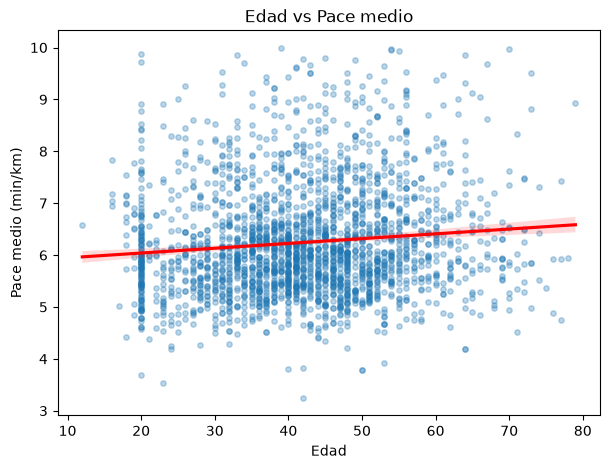

In [14]:
# --- 4.1 Edad vs pace ---
print(athletes_unique[["age", "avg_pace"]].corr())

plt.figure(figsize=(7,5))
sns.regplot(data=athletes_unique, x="age", y="avg_pace",
            scatter_kws={"alpha":0.3, "s":15}, line_kws={"color":"red"})
plt.title("Edad vs Pace medio")
plt.xlabel("Edad")
plt.ylabel("Pace medio (min/km)")
plt.show()

Peso vs pace: correlación positiva débil (r=0.17), algo más marcada que la edad pero sigue siendo débil. Tiene sentido fisiológico (más peso, más coste energético por km)

          weightkg  avg_pace
weightkg  1.000000  0.168211
avg_pace  0.168211  1.000000


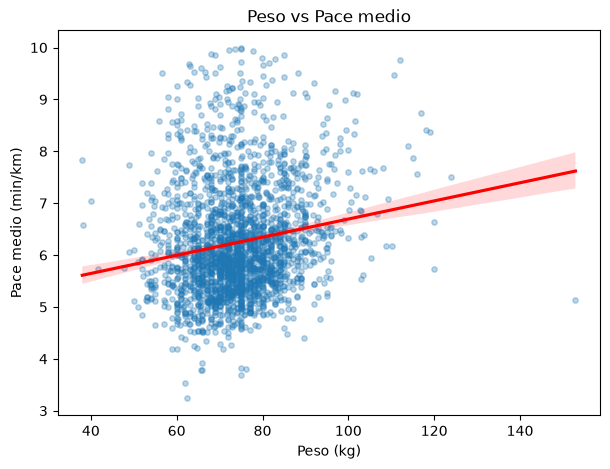

In [15]:
# --- 4.2 Peso vs pace ---
print(athletes_unique[["weightkg", "avg_pace"]].corr())

plt.figure(figsize=(7,5))
sns.regplot(data=athletes_unique, x="weightkg", y="avg_pace",
            scatter_kws={"alpha":0.3, "s":15}, line_kws={"color":"red"})
plt.title("Peso vs Pace medio")
plt.xlabel("Peso (kg)")
plt.ylabel("Pace medio (min/km)")
plt.show()

Género vs pace: aquí sí hay una diferencia más visible — las mujeres de la muestra tienen un pace medio más lento (6:40 vs 6:14 en hombres), pero hay que ser muy cautos con esta lectura: solo 74 mujeres frente a 2.305 hombres. Con una muestra tan pequeña del grupo femenino los resultados no son representativos.

         count      mean       std       min       25%       50%       75%  \
gender                                                                       
F         74.0  6.669382  1.112987  5.100330  5.819864  6.365758  7.392764   
M       2305.0  6.229509  1.055226  3.245695  5.493125  6.009635  6.743571   

             max  
gender            
F       9.858674  
M       9.990555  


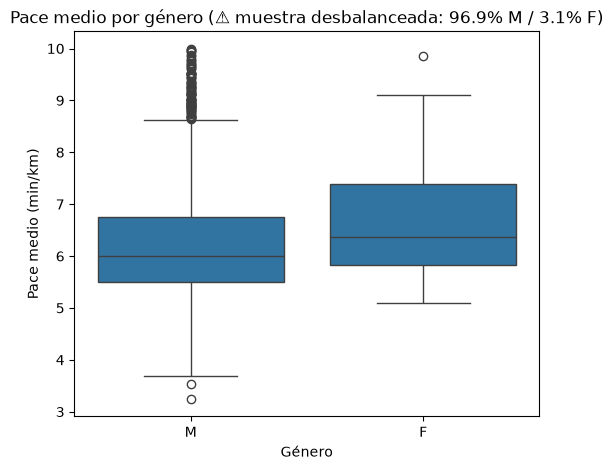

In [16]:
# --- 4.3 Género vs pace (con aviso de muestra desbalanceada) ---
print(athletes_unique.groupby("gender")["avg_pace"].describe())

plt.figure(figsize=(6,5))
sns.boxplot(data=athletes_unique, x="gender", y="avg_pace")
plt.title("Pace medio por género (⚠️ muestra desbalanceada: 96.9% M / 3.1% F)")
plt.xlabel("Género")
plt.ylabel("Pace medio (min/km)")
plt.show()

En resumen, de las variables de perfil del corredor, ninguna (edad, peso, género) muestra una relación fuerte por sí sola con el pace

# 5. Fisiologia y condiciones actividad

HR vs pace: esta es la correlación más fuerte que hemos visto hasta ahora (r=-0.35). Como el pace está en min/km (menor = más rápido), la correlación negativa significa: a mayor frecuencia cardíaca media, más rápido el ritmo. Tiene mucho sentido fisiológico: correr más rápido exige más esfuerzo cardiovascular, así que HR alta y pace bajo van de la mano dentro de una misma actividad.

Actividades con HR registrado: 177702 de 216549 (82.1%)
             average_hr  pace_min_km
average_hr     1.000000    -0.352246
pace_min_km   -0.352246     1.000000


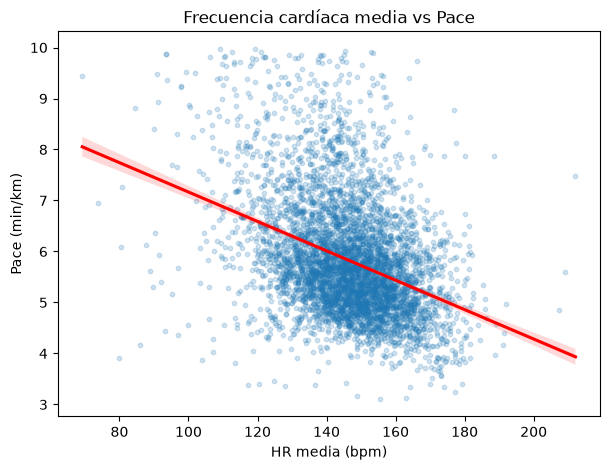

In [17]:
# --- 5.1 Frecuencia cardíaca vs pace (solo actividades con HR real, sin NaN) ---
df_hr = final_df.dropna(subset=["average_hr"])
print(f"Actividades con HR registrado: {len(df_hr)} de {len(final_df)} ({len(df_hr)/len(final_df)*100:.1f}%)")

print(df_hr[["average_hr", "pace_min_km"]].corr())

plt.figure(figsize=(7,5))
sns.regplot(data=df_hr.sample(min(5000, len(df_hr)), random_state=42), 
            x="average_hr", y="pace_min_km",
            scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Frecuencia cardíaca media vs Pace")
plt.xlabel("HR media (bpm)")
plt.ylabel("Pace (min/km)")
plt.show()

Elevación vs pace: correlación prácticamente nula (r=0.004). Esto es sorprendente a primera vista — uno esperaría que más desnivel penalice el ritmo. Seguramente estamos tretando el desnivel acumulado total, no nos da información relevante en este caso.

Actividades con elevation registrada: 188739 de 216549 (87.2%)
                elevation_gain  pace_min_km
elevation_gain        1.000000     0.003664
pace_min_km           0.003664     1.000000


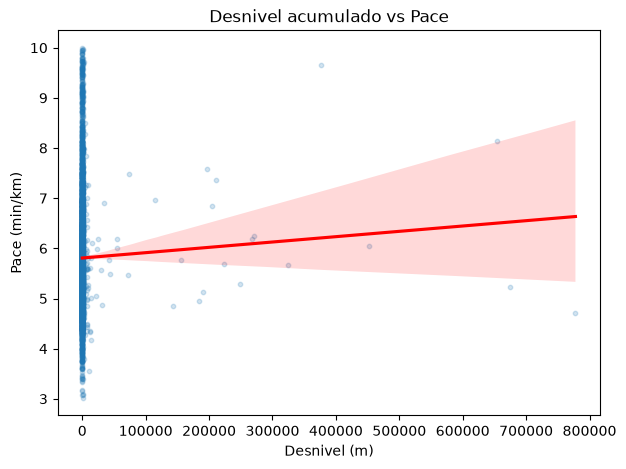

In [20]:
# --- 5.2 Desnivel vs pace (solo actividades con elevation registrada) ---
df_elev = final_df.dropna(subset=["elevation_gain"])
print(f"Actividades con elevation registrada: {len(df_elev)} de {len(final_df)} ({len(df_elev)/len(final_df)*100:.1f}%)")

print(df_elev[["elevation_gain", "pace_min_km"]].corr())

plt.figure(figsize=(7,5))
sns.regplot(data=df_elev.sample(min(5000, len(df_elev)), random_state=42),
            x="elevation_gain", y="pace_min_km",
            scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Desnivel acumulado vs Pace")
plt.xlabel("Desnivel (m)")
plt.ylabel("Pace (min/km)")
plt.show()

Pace por distancia: aquí aparece un patrón claro y con sentido: las distancias largas y muy largas (10-21km, >21km) tienen mejor pace medio (~5:33-5:33) que las cortas (<5km, ~6:10). Esto puede parecer contraintuitivo (¿no debería cansarse más en distancias largas?), pero se explica bien: quien corre 15-20km+ suele ser un corredor más entrenado/serio, mientras que las actividades cortas incluyen trotes suaves, calentamientos, o corredores principiantes

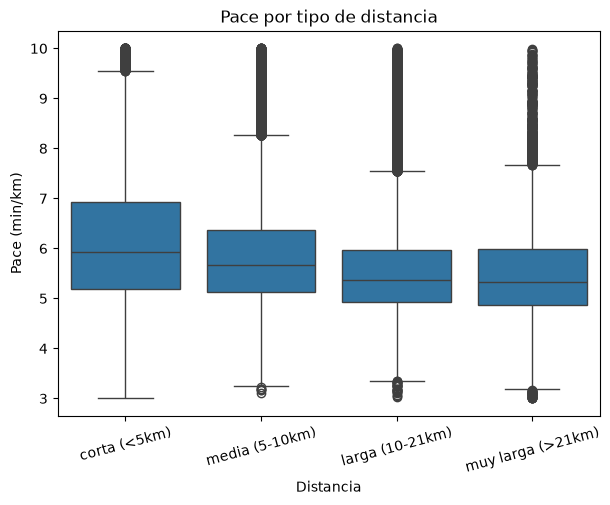

                     count      mean       std       min       25%       50%  \
distance_bucket                                                                
corta (<5km)       43706.0  6.166849  1.383198  3.002669  5.191581  5.918532   
larga (10-21km)    73061.0  5.554802  0.937288  3.026976  4.919667  5.378426   
media (5-10km)     90652.0  5.864762  1.081483  3.107301  5.120604  5.660366   
muy larga (>21km)   9130.0  5.527281  1.050919  3.001141  4.860983  5.328483   

                        75%        max  
distance_bucket                         
corta (<5km)       6.937088  10.000000  
larga (10-21km)    5.968110  10.000000  
media (5-10km)     6.376238  10.000000  
muy larga (>21km)  5.983494   9.996682  


In [21]:
# --- 5.3 Pace por distance_bucket ---
plt.figure(figsize=(7,5))
sns.boxplot(data=final_df, x="distance_bucket", y="pace_min_km",
            order=["corta (<5km)", "media (5-10km)", "larga (10-21km)", "muy larga (>21km)"])
plt.title("Pace por tipo de distancia")
plt.xlabel("Distancia")
plt.ylabel("Pace (min/km)")
plt.xticks(rotation=15)
plt.show()

print(final_df.groupby("distance_bucket")["pace_min_km"].describe())

# 6. Evolución temporal

El pace medio empeora ligeramente año tras año, pasando de 5:34 min/km (2007) a 5:59 min/km (2020), puede deberse a nuevos usuarios que van entrando o que cada vez hay mas atletas registrando datos.

          mean       std  count
year                           
2007  5.562631  0.666878     78
2008  5.418652  0.944092    189
2009  5.257805  0.742673    406
2010  5.573364  1.006108   1237
2011  5.452321  1.006926   3057
2012  5.560881  1.038674   4915
2013  5.607168  1.016344   6537
2014  5.634161  1.036279   9716
2015  5.693030  1.064825  16418
2016  5.757937  1.124163  27781
2017  5.824878  1.122597  43182
2018  5.860755  1.152283  57540
2019  5.912423  1.163150  38848
2020  5.978821  1.120037   6645


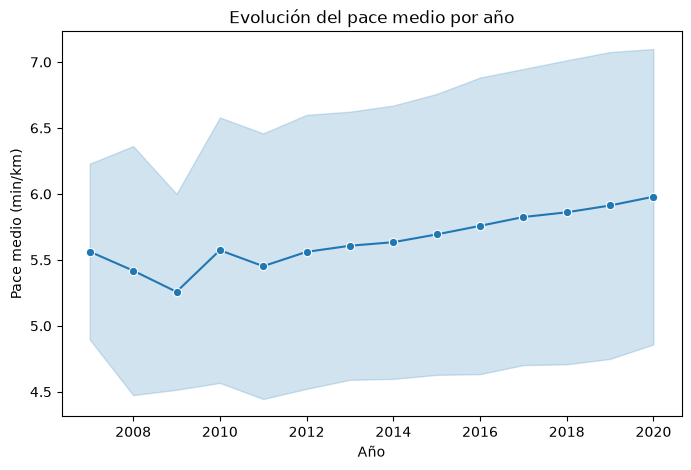

In [22]:
# --- 6.1 Pace medio por año ---
pace_by_year = final_df.groupby("year")["pace_min_km"].agg(["mean", "std", "count"])
print(pace_by_year)

plt.figure(figsize=(8,5))
sns.lineplot(data=final_df, x="year", y="pace_min_km", marker="o", errorbar="sd")
plt.title("Evolución del pace medio por año")
plt.xlabel("Año")
plt.ylabel("Pace medio (min/km)")
plt.show()

La estacionalidad es mínima y no encontramos ningún patrón estacional.

           mean       std  count
month                           
1      5.837391  1.117904  21372
2      5.817218  1.138084  18011
3      5.778399  1.120671  19142
4      5.790279  1.137918  18302
5      5.777126  1.153163  17478
6      5.766062  1.130990  16235
7      5.847977  1.132954  16599
8      5.839868  1.130152  17219
9      5.801535  1.120096  17350
10     5.792319  1.112608  18599
11     5.810743  1.106992  17734
12     5.820304  1.126863  18508


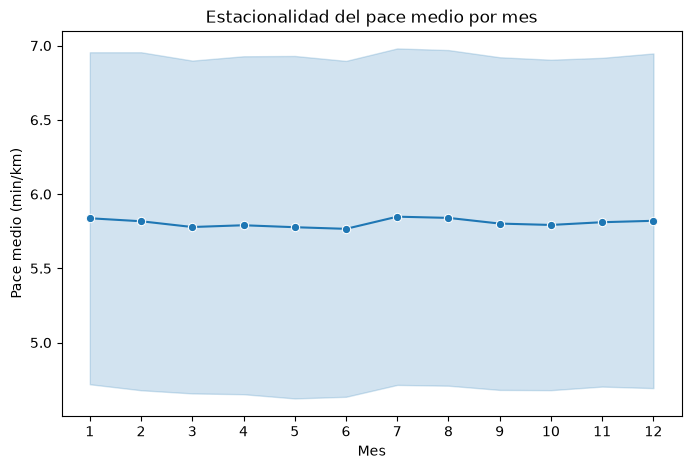

In [23]:
# --- 6.2 Pace medio por mes (estacionalidad, ¿clima?) ---
pace_by_month = final_df.groupby("month")["pace_min_km"].agg(["mean", "std", "count"])
print(pace_by_month)

plt.figure(figsize=(8,5))
sns.lineplot(data=final_df, x="month", y="pace_min_km", marker="o", errorbar="sd")
plt.title("Estacionalidad del pace medio por mes")
plt.xlabel("Mes")
plt.ylabel("Pace medio (min/km)")
plt.xticks(range(1,13))
plt.show()

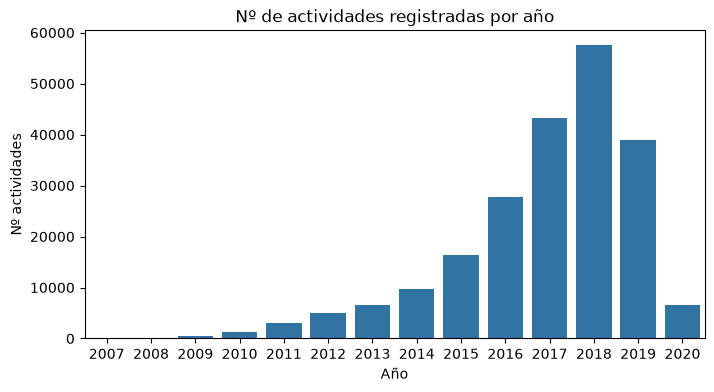

In [24]:
# --- 6.3 Volumen de actividades por año (para contextualizar si el pace por año es fiable) ---
plt.figure(figsize=(8,4))
sns.barplot(data=pace_by_year.reset_index(), x="year", y="count")
plt.title("Nº de actividades registradas por año")
plt.xlabel("Año")
plt.ylabel("Nº actividades")
plt.show()

El pace medio muestra un ligero empeoramiento progresivo entre 2007 y 2020 (de 5:34 a 5:59 min/km). Sin embargo, este patrón coincide con un fuerte crecimiento en el volumen de usuarios de la plataforma en el mismo periodo (de <100 a 57.000+ actividades/año), por lo que es más plausible atribuirlo a un cambio en la composición de la muestra —de un núcleo inicial de usuarios muy entrenados a una base más amplia y diversa— que a una tendencia real de rendimiento a lo largo del tiempo.

# 7. Análisis estadístico

                    avg_pace  weekly_km  training_frequency       age  \
avg_pace            1.000000  -0.261734           -0.156460  0.105293   
weekly_km          -0.261734   1.000000            0.874365  0.017421   
training_frequency -0.156460   0.874365            1.000000  0.027964   
age                 0.105293   0.017421            0.027964  1.000000   
weightkg            0.168211  -0.078390           -0.047705  0.112324   

                    weightkg  
avg_pace            0.168211  
weekly_km          -0.078390  
training_frequency -0.047705  
age                 0.112324  
weightkg            1.000000  


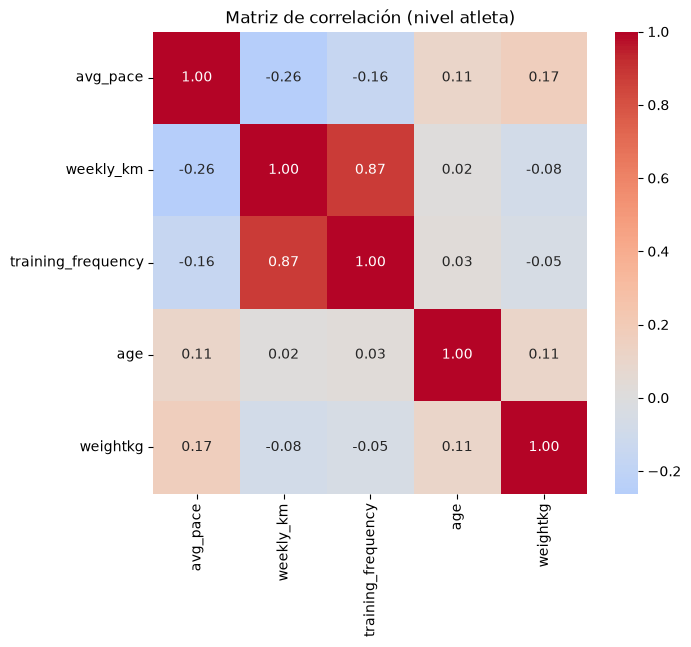

In [25]:
# --- 7.1 Matriz de correlación completa ---
cols_corr = ["avg_pace", "weekly_km", "training_frequency", "age", "weightkg"]
corr_matrix = athletes_unique[cols_corr].corr()
print(corr_matrix)

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (nivel atleta)")
plt.show()

In [26]:
# --- 7.2 Preparar datos para la regresión ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

df_model = athletes_unique.dropna(subset=["avg_pace", "weekly_km", "training_frequency", "age", "weightkg"]).copy()
df_model["gender_num"] = (df_model["gender"] == "M").astype(int)  # 1=M, 0=F

features = ["weekly_km", "training_frequency", "age", "weightkg", "gender_num"]
X = df_model[features]
y = df_model["avg_pace"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Filas entrenamiento:", len(X_train))
print("Filas test:", len(X_test))

Filas entrenamiento: 1903
Filas test: 476


In [ ]:
# --- 7.3 Regresión lineal ---
features = ["weekly_km", "age", "weightkg", "gender_num"]
X = df_model[features]
y = df_model["avg_pace"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f} min/km ({min_a_min_seg(mae)} min:seg)")
print("\nCoeficientes:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  intercepto: {model.intercept_:.4f}")

R²: 0.130
MAE: 0.748 min/km (0:45 min:seg)

Coeficientes:
  weekly_km: -0.0208
  age: 0.0076
  weightkg: 0.0168
  gender_num: -0.6740
  intercepto: 5.5798


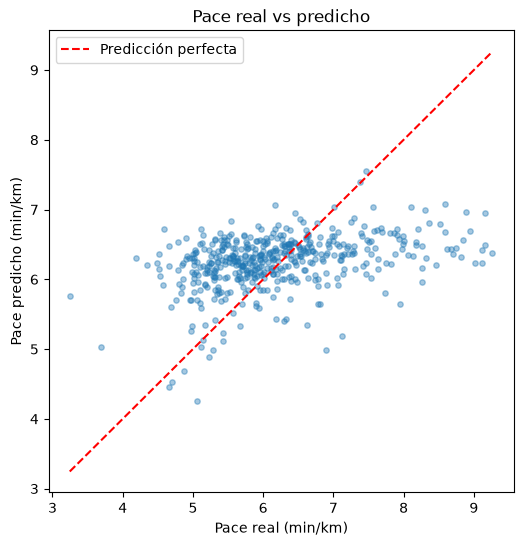

In [28]:
# --- 7.4 Real vs predicho ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Predicción perfecta")
plt.xlabel("Pace real (min/km)")
plt.ylabel("Pace predicho (min/km)")
plt.title("Pace real vs predicho")
plt.legend()
plt.show()

El modelo de regresión lineal (pace ~ km semanales + edad + peso + género) explica el 13% de la variabilidad del pace medio (R²=0.130), con un error medio de 45 segundos/km (MAE=0.748). 

El volumen de entrenamiento semanal es la variable con mayor peso entre las de entrenamiento: cada 10 km/semana adicionales se asocian con una mejora de aproximadamente 12 segundos/km. 

La edad y el peso muestran efectos pequeños pero en la dirección esperada (más edad y más peso, ligero empeoramiento del ritmo). 

El género muestra la asociación más marcada del modelo, aunque debe interpretarse con cautela dado el fuerte desequilibrio muestral. 

En conjunto, el poder explicativo limitado del modelo sugiere que factores no incluidos en el dataset —como la técnica de carrera, la genética o los años reales de experiencia corriendo— juegan un papel relevante en el rendimiento.